In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import os

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from textblob import TextBlob
from wordcloud import WordCloud

In [2]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gxawu\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gxawu\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\gxawu\AppData\Roaming\nltk_data...


True

In [3]:
df = pd.read_csv("Data Set For Task/3) Sentiment dataset.csv")

df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [4]:
df.shape

df.info()

df.isnull().sum()

df.columns


<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    str    
 3   Sentiment     732 non-null    str    
 4   Timestamp     732 non-null    str    
 5   User          732 non-null    str    
 6   Platform      732 non-null    str    
 7   Hashtags      732 non-null    str    
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    str    
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), str(7)
memory usage: 85.9 KB


Index(['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User',
       'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month',
       'Day', 'Hour'],
      dtype='str')

In [5]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns

Index(['unnamed:_0.1', 'unnamed:_0', 'text', 'sentiment', 'timestamp', 'user',
       'platform', 'hashtags', 'retweets', 'likes', 'country', 'year', 'month',
       'day', 'hour'],
      dtype='str')

In [6]:
text_column = "text"

df[[text_column, "sentiment"]].head()

,text,sentiment
0,Enjoying a beautiful day at the park! ...,Positive
1,Traffic was terrible this morning. ...,Negative
2,Just finished an amazing workout! 💪 ...,Positive
3,Excited about the upcoming weekend getaway! ...,Positive
4,Trying out a new recipe for dinner tonight. ...,Neutral


In [7]:
df = df.loc[:, ~df.columns.str.contains("^unnamed")]

df.head()

,text,sentiment,timestamp,user,platform,hashtags,retweets,likes,country,year,month,day,hour
0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [8]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Convert text to string and lowercase
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    
    # Remove mentions and hashtags
    text = re.sub(r"@\w+|#\w+", "", text)
    
    # Remove numbers, punctuation, and special characters
    text = re.sub(r"[^a-z\s]", "", text)
    
    # Tokenization
    words = text.split()
    
    # Remove stopwords and lemmatize words
    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    
    return " ".join(cleaned_words)

In [9]:
df["cleaned_text"] = df[text_column].apply(clean_text)

df[[text_column, "cleaned_text"]].head()

,text,cleaned_text
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park
1,Traffic was terrible this morning. ...,traffic terrible morning
2,Just finished an amazing workout! 💪 ...,finished amazing workout
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight


In [10]:
def get_sentiment_score(text):
    return TextBlob(text).sentiment.polarity

df["sentiment_score"] = df["cleaned_text"].apply(get_sentiment_score)

df[[text_column, "cleaned_text", "sentiment_score"]].head()

,text,cleaned_text,sentiment_score
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park,0.675000
1,Traffic was terrible this morning. ...,traffic terrible morning,-1.000000
2,Just finished an amazing workout! 💪 ...,finished amazing workout,0.600000
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway,0.375000
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight,0.136364


In [11]:
def classify_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["predicted_sentiment"] = df["sentiment_score"].apply(classify_sentiment)

df[[text_column, "cleaned_text", "sentiment_score", "predicted_sentiment"]].head()

,text,cleaned_text,sentiment_score,predicted_sentiment
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park,0.675000,Positive
1,Traffic was terrible this morning. ...,traffic terrible morning,-1.000000,Negative
2,Just finished an amazing workout! 💪 ...,finished amazing workout,0.600000,Positive
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway,0.375000,Positive
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight,0.136364,Positive


In [12]:
df[["sentiment", "predicted_sentiment"]].head(10)

,sentiment,predicted_sentiment
0,Positive,Positive
1,Negative,Negative
2,Positive,Positive
3,Positive,Positive
4,Neutral,Positive
5,Positive,Negative
6,Positive,Positive
7,Positive,Positive
8,Negative,Neutral
9,Neutral,Negative


In [13]:
sentiment_counts = df["predicted_sentiment"].value_counts()

sentiment_counts

predicted_sentiment
Neutral     334
Positive    288
Negative    110
Name: count, dtype: int64

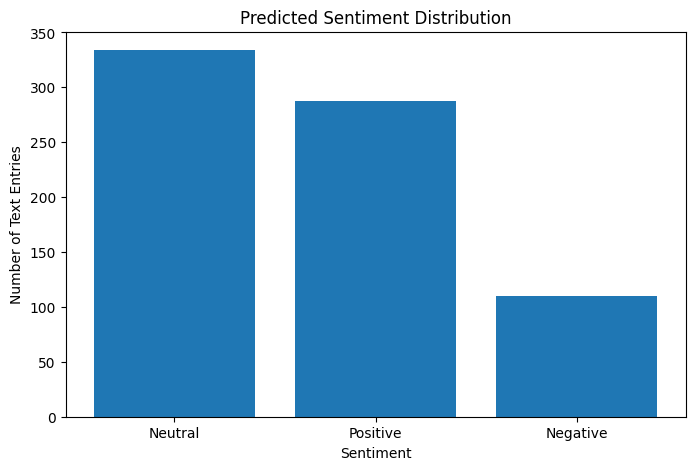

In [14]:
plt.figure(figsize=(8, 5))

plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Predicted Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Text Entries")

plt.show()

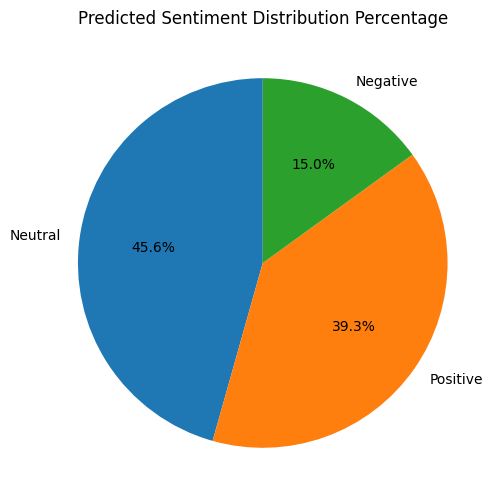

In [15]:
plt.figure(figsize=(6, 6))

plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Predicted Sentiment Distribution Percentage")
plt.show()

In [16]:
all_words = " ".join(df["cleaned_text"])

all_words[:500]

'enjoying beautiful day park traffic terrible morning finished amazing workout excited upcoming weekend getaway trying new recipe dinner tonight feeling grateful little thing life rainy day call cozy blanket hot cocoa new movie release mustwatch political discussion heating timeline missing summer vibe beach day published new blog post check feeling bit weather today exploring city hidden gem new year new fitness goal technology changing way live reflecting past looking ahead adopted cute furry f'

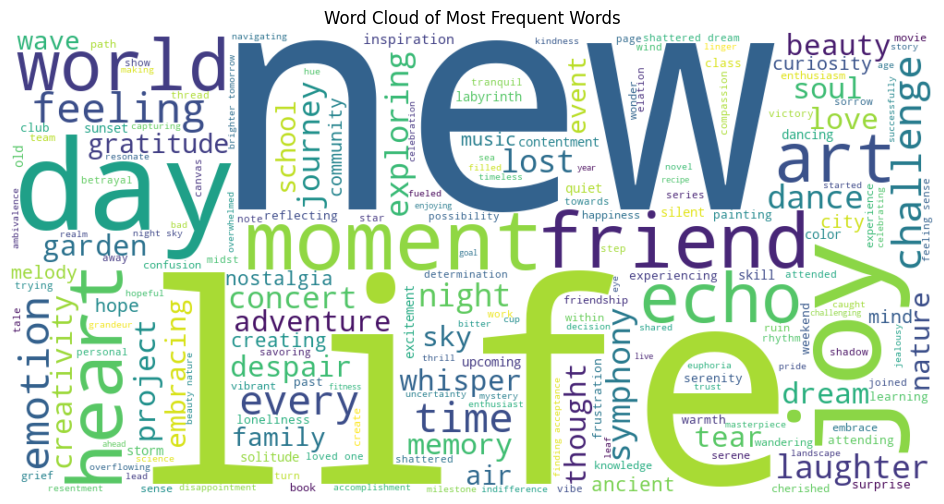

In [17]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Most Frequent Words")
plt.show()

In [18]:
os.makedirs("nlp_outputs", exist_ok=True)

df.to_csv("nlp_outputs/sentiment_analysis_results.csv", index=False)

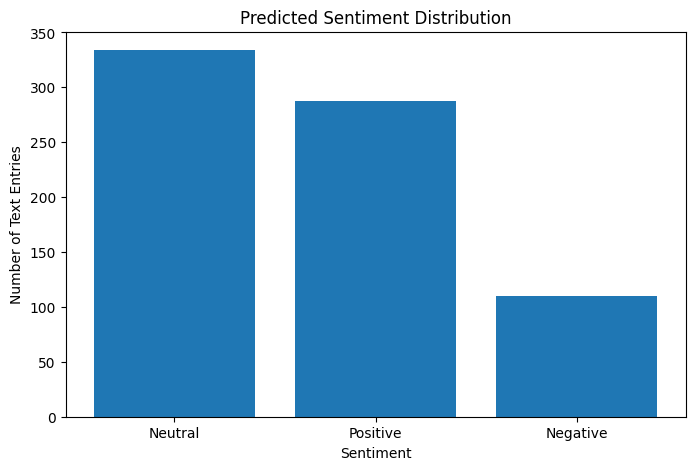

In [19]:
plt.figure(figsize=(8, 5))

plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Predicted Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Text Entries")

plt.savefig("nlp_outputs/sentiment_distribution.png", bbox_inches="tight")
plt.show()

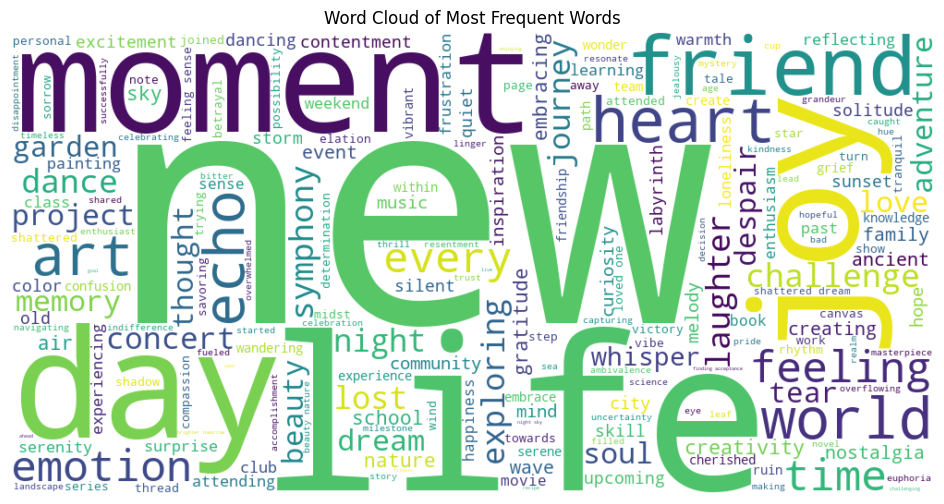

In [20]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Most Frequent Words")

plt.savefig("nlp_outputs/word_cloud.png", bbox_inches="tight")
plt.show()

## Level 3 Task 3: NLP - Sentiment Analysis Summary

For this task, I performed sentiment analysis on a textual dataset using Python, pandas, nltk, TextBlob, matplotlib, and WordCloud.

The dataset contained 732 rows and 15 columns. The main text column used for analysis was `text`. The dataset also contained an original `sentiment` column, but TextBlob was used to generate new predicted sentiment categories.

The text data was preprocessed by converting it to lowercase, removing URLs, mentions, hashtags, numbers, punctuation, and stopwords. Lemmatization was also applied to reduce words to their base form.

TextBlob was used to calculate sentiment polarity scores for each cleaned text entry. These scores were then classified into three categories: Positive, Negative, and Neutral.

The predicted sentiment distribution was visualized using a bar chart and pie chart. A word cloud was also created to show the most frequent words in the cleaned text data.

The final results were saved as `sentiment_analysis_results.csv`, and the sentiment distribution and word cloud were exported as image files.